# Conformity Score Distribution by Model

**Purpose:** Histogram of the composite ConformityScore (`NSI + INSI + ISI`) per frontier judge model.

**Reference:** Scoring rubric in [`papers/publication1/CONFORMITY_SYSTEM_PROMPT.md`](../papers/publication1/CONFORMITY_SYSTEM_PROMPT.md). Judge configuration and table structure in [`docs/DB_SCHEMA.md`](../docs/DB_SCHEMA.md).

In [17]:
import sys
from pathlib import Path

# Add repo root to sys.path so notebooks.lib can be imported
here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "project_config.py").is_file():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

In [18]:
import pandas as pd
from IPython.display import Markdown, display

from notebooks.lib import connect, DB_PATH, load_scores_with_metadata

print(f"DB: {DB_PATH.resolve()}  exists={DB_PATH.is_file()}")

DB: /Users/naataaniitsosie/repos/swe-principals/data/raw/events.db  exists=True


## Judge Models and Coverage

Which models scored comments, and how many scores did each model produce?

In [19]:
with connect() as conn:
    models_df = pd.read_sql(
        """
        SELECT
            experiment_version,
            model_name,
            COUNT(*) AS n_total,
            SUM(CASE WHEN parse_ok = 1 THEN 1 ELSE 0 END) AS n_scores,
            SUM(CASE WHEN parse_ok = 0 THEN 1 ELSE 0 END) AS n_failures
        FROM scores
        GROUP BY experiment_version, model_name
        ORDER BY experiment_version, n_total DESC
        """,
        conn
    )

display(Markdown("**Score rows per judge model:**"))
display(models_df)

with connect() as conn:
    total_sampled = int(pd.read_sql("SELECT COUNT(*) FROM samples", conn)["COUNT(*)"].iloc[0])

display(Markdown(f"\n**Context:** {total_sampled:,} comments in the stratified sample. Each model above scored this corpus."))

**Score rows per judge model:**

,experiment_version,model_name,n_total,n_scores,n_failures
0,1,openai/gpt-5.4-mini,1903,1902,1
1,1,google/gemini-2.5-flash,1903,1883,20
2,1,anthropic/claude-haiku-4-5,1903,1894,9
3,1,gemma4:26b,100,55,45



**Context:** 1,903 comments in the stratified sample. Each model above scored this corpus.

## Conformity Score Distribution by Model

`ConformityScore = nsi_score + insi_score + isi_score` (range 0–9), computed in memory. Rows with ConformityScore = 0 are excluded. One histogram per judge model.

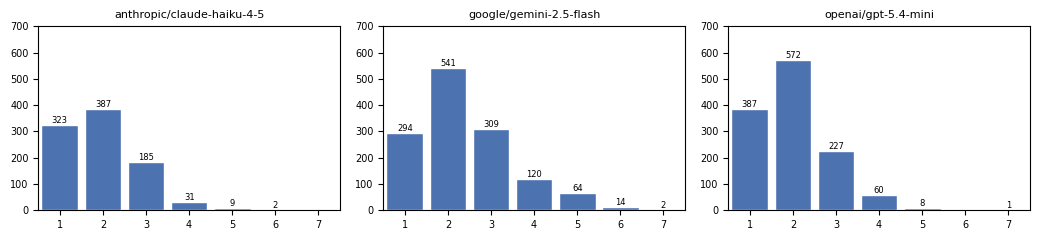

Conformity score: NSI + INSI + ISI (each 0–3), range 0–9. FUN is excluded — it measures
functional correctness, not social conformity pressure.

Non-zero conformity score rates per model:
  anthropic/claude-haiku-4-5: 937 / 1,894 (49.5%)
  google/gemini-2.5-flash: 1,344 / 1,883 (71.4%)
  openai/gpt-5.4-mini: 1,255 / 1,902 (66.0%)

Note: scores 8 and 9 were never observed (max observed = 7); x-axis capped at 7 intentionally.


In [20]:
import matplotlib.pyplot as plt
import numpy as np

FRONTIER_MODELS = [
    "openai/gpt-5.4-mini",
    "google/gemini-2.5-flash",
    "anthropic/claude-haiku-4-5",
]

df_cs = load_scores_with_metadata(model_allowlist=FRONTIER_MODELS).copy()
for c in ["nsi_score", "insi_score", "isi_score"]:
    df_cs[c] = pd.to_numeric(df_cs[c], errors="coerce").fillna(0).astype(int)

df_cs["conformity_score"] = df_cs["nsi_score"] + df_cs["insi_score"] + df_cs["isi_score"]
n_total = len(df_cs)
df_cs_nonzero = df_cs[df_cs["conformity_score"] > 0]

models = sorted(df_cs_nonzero["model_name"].unique())
bins = np.arange(1, 9) - 0.5  # bins centered on integers 1–7

fig, axes = plt.subplots(1, len(models), figsize=(3.5 * len(models), 2.5), sharey=False)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    scores = df_cs_nonzero.loc[df_cs_nonzero["model_name"] == model, "conformity_score"]
    ax.hist(scores, bins=bins, color="#4c72b0", edgecolor="white", rwidth=0.85)
    ax.set_title(model, fontsize=8)
    ax.set_xticks(range(1, 8))
    ax.set_xlim(0.5, 7.5)
    ax.set_ylim(0, 700)
    ax.tick_params(axis="both", labelsize=7)
    for xi in range(1, 8):
        n = int((scores == xi).sum())
        if n > 0:
            ax.text(xi, n, str(n), ha="center", va="bottom", fontsize=6)

plt.tight_layout()
plt.show()

print("Conformity score: NSI + INSI + ISI (each 0–3), range 0–9. FUN is excluded — it measures")
print("functional correctness, not social conformity pressure.")
print()
print("Non-zero conformity score rates per model:")
for model in sorted(FRONTIER_MODELS):
    n_model_total = int((df_cs["model_name"] == model).sum())
    n_model_nonzero = int((df_cs_nonzero["model_name"] == model).sum())
    pct = 100 * n_model_nonzero / n_model_total if n_model_total > 0 else 0
    print(f"  {model}: {n_model_nonzero:,} / {n_model_total:,} ({pct:.1f}%)")

max_observed = int(df_cs["conformity_score"].max())
print(f"\nNote: scores 8 and 9 were never observed (max observed = {max_observed}); x-axis capped at 7 intentionally.")

## This Figure _Detects_ Conformity
After conducting experiments on frontier models, we see see a right tailed graph proving, according to our prompting strategy, signals of social conformity inside PR discourse.

## Items to Address
1. Haiku detects conformity signal in only 49.5% of comments. Gemini detects it in 71.4%. That's a 22-point gap. A reader will notice this and wonder if it's a calibration difference between judges, or a real difference in what each model considers a conformity signal. You need at least one sentence acknowledging this — either in the caption or the surrounding prose.

2. **A score from 1-3 is normal, expected, and probably our best signal**. Is the score from one score or multiple? The caption says max observed is 7, which means NSI + INSI + ISI all scored 3 simultaneously on at least a few comments. That's worth a sentence — those are your most saturated conformity events and they're rare but real.

3. Zero's are filtered out

4. This scoring method is not contextual accross PRs. Contextual discourse is a topic for future work.